# Medical Insurance Cost Prediction — Phase 1

## Problem Statement
The goal of this project is to build a machine learning model that predicts an individual's medical insurance cost based on personal and lifestyle factors.

## Problem Type
This is a **Regression Problem** because the model predicts a continuous numerical value.

## Why This Problem Is Important
Medical insurance costs can vary greatly between individuals. Predicting these costs can help organizations better understand healthcare expenses, estimate future costs, and make more informed financial decisions.

## Who Can Benefit?
Insurance companies can benefit by estimating expected customer costs and improving financial planning. Analysts and healthcare-related organizations can also use such predictions to better understand the factors that influence medical expenses.

## Target Variable
**charges** — the medical insurance cost that the model will predict.

## Input Features
- **age** – Age of the individual
- **sex** – Gender
- **bmi** – Body Mass Index
- **children** – Number of dependent children
- **smoker** – Smoking status
- **region** – Residential region

## Real-World Use Case
Insurance companies can use historical customer data to estimate expected medical costs. Such predictions can support cost analysis, risk assessment, and financial planning.

# Phase 2 — Dataset Collection & Exploration

## Dataset Source
- **Source:** Kaggle — Medical Cost Personal Datasets
- **File:** insurance.csv
- **Format:** CSV
- **Records:** 1,338
- **Columns:** 7
- **Input Features:** age, sex, bmi, children, smoker, region
- **Target Variable:** charges

This dataset is suitable for the project because it contains demographic and lifestyle information that can be used to predict individual medical insurance charges.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [2]:
import pandas as pd

df = pd.read_csv("insurance.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print("Dataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (1338, 7)
Number of Rows: 1338
Number of Columns: 7


In [5]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


# Phase 3 — Data Cleaning & Preprocessing

In this phase, the dataset is inspected for missing values, duplicate records,
incorrect data types, inconsistent values, and categorical variables.

The goal is to clean the data and convert categorical features into numerical
form so that the dataset is ready for machine learning.

In [9]:
# Create a copy so the original dataset remains unchanged
df_clean = df.copy()

print("Working copy created successfully.")
print("Original shape:", df.shape)
print("Working shape:", df_clean.shape)

Working copy created successfully.
Original shape: (1338, 7)
Working shape: (1338, 7)


In [10]:
print("Missing Values:")
print(df_clean.isnull().sum())

print("\nTotal Missing Values:", df_clean.isnull().sum().sum())

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total Missing Values: 0


In [11]:
missing_percent = (df_clean.isnull().sum() / len(df_clean)) * 100

missing_analysis = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Missing Percentage": missing_percent
})

missing_analysis

,Missing Values,Missing Percentage
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0


In [12]:
duplicate_count = df_clean.duplicated().sum()

print("Duplicate Records:", duplicate_count)

Duplicate Records: 1


In [13]:
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Duplicates after cleaning:", df_clean.duplicated().sum())
print("Dataset shape after duplicate removal:", df_clean.shape)

Duplicates after cleaning: 0
Dataset shape after duplicate removal: (1337, 7)


In [14]:
print("Dataset Data Types:")
print(df_clean.dtypes)

Dataset Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [15]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.2+ KB


In [16]:
categorical_columns = df_clean.select_dtypes(include="object").columns.tolist()
numerical_columns = df_clean.select_dtypes(exclude="object").columns.tolist()

print("Categorical Columns:", categorical_columns)
print("Numerical Columns:", numerical_columns)

Categorical Columns: ['sex', 'smoker', 'region']
Numerical Columns: ['age', 'bmi', 'children', 'charges']


In [17]:
for column in categorical_columns:
    print(f"{column}: {df_clean[column].unique()}")

sex: ['female' 'male']
smoker: ['yes' 'no']
region: ['southwest' 'southeast' 'northwest' 'northeast']


In [18]:
print("Dataset BEFORE Encoding:")
display(df_clean.head())

Dataset BEFORE Encoding:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
df_encoded = pd.get_dummies(
    df_clean,
    columns=["sex", "smoker", "region"],
    drop_first=True,
    dtype=int
)

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


In [20]:
print("Dataset AFTER Encoding:")
display(df_encoded.head())

Dataset AFTER Encoding:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [21]:
print("Final Data Types:")
print(df_encoded.dtypes)

print("\nRemaining Categorical Columns:")
print(df_encoded.select_dtypes(include="object").columns.tolist())

Final Data Types:
age                   int64
bmi                 float64
children              int64
charges             float64
sex_male              int64
smoker_yes            int64
region_northwest      int64
region_southeast      int64
region_southwest      int64
dtype: object

Remaining Categorical Columns:
[]


In [22]:
print("Final Dataset Shape:", df_encoded.shape)
print("Missing Values:", df_encoded.isnull().sum().sum())
print("Duplicate Records:", df_encoded.duplicated().sum())

display(df_encoded.head())

Final Dataset Shape: (1337, 9)
Missing Values: 0
Duplicate Records: 0


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [23]:
print("Target Variable: charges")
print("Input Features:")

for column in df_encoded.columns:
    if column != "charges":
        print("-", column)

Target Variable: charges
Input Features:
- age
- bmi
- children
- sex_male
- smoker_yes
- region_northwest
- region_southeast
- region_southwest


## Preprocessing Summary

- The dataset was inspected for missing values and duplicate records.
- Duplicate observations were removed where present.
- Data types and categorical values were reviewed for consistency.
- The categorical features `sex`, `smoker`, and `region` were converted into numerical form using one-hot encoding.
- The target variable `charges` was kept unchanged.
- The final dataset contains only numerical features and is ready for machine learning.

# Phase 4 — Exploratory Data Analysis

In this phase, the cleaned dataset is explored to identify patterns and
relationships between medical insurance charges and important features.

The analysis focuses mainly on age, BMI, smoking status, and their relationship
with the target variable `charges`.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

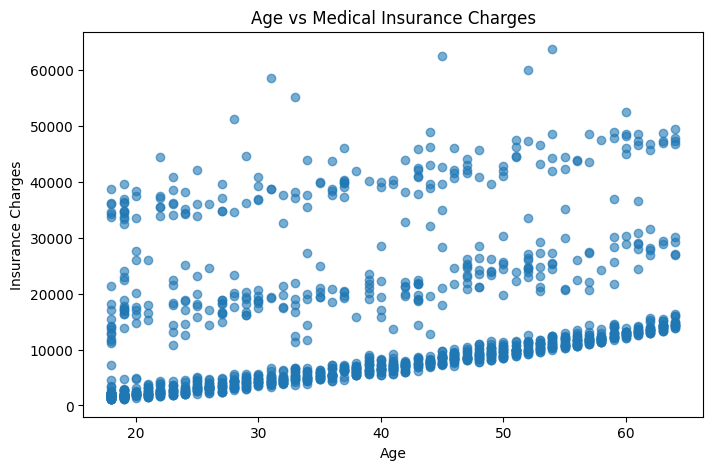

In [25]:
plt.figure(figsize=(8, 5))

plt.scatter(df_clean["age"], df_clean["charges"], alpha=0.6)

plt.title("Age vs Medical Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")

plt.show()

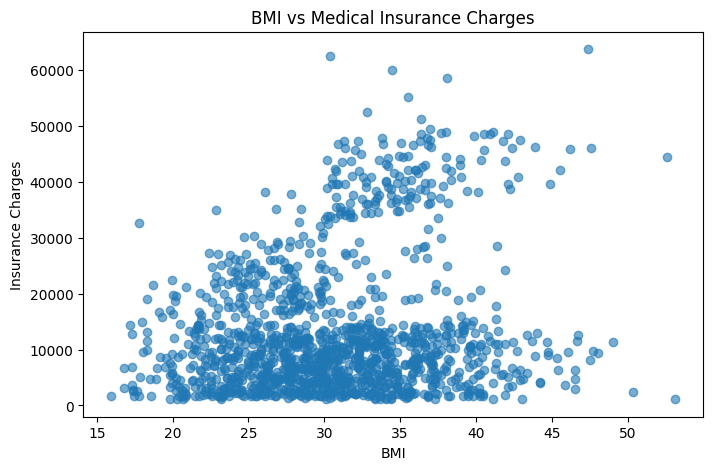

In [26]:
plt.figure(figsize=(8, 5))

plt.scatter(df_clean["bmi"], df_clean["charges"], alpha=0.6)

plt.title("BMI vs Medical Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.show()

/tmp/ipykernel_2073/3155796678.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(smoker_groups, labels=["Non-Smoker", "Smoker"])


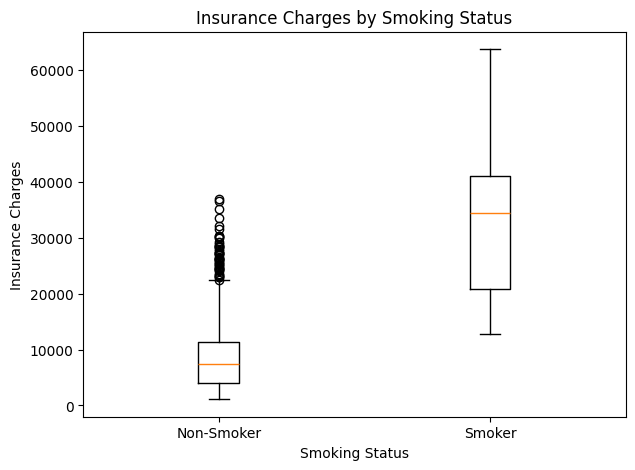

In [27]:
smoker_groups = [
    df_clean[df_clean["smoker"] == "no"]["charges"],
    df_clean[df_clean["smoker"] == "yes"]["charges"]
]

plt.figure(figsize=(7, 5))

plt.boxplot(smoker_groups, labels=["Non-Smoker", "Smoker"])

plt.title("Insurance Charges by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Insurance Charges")

plt.show()

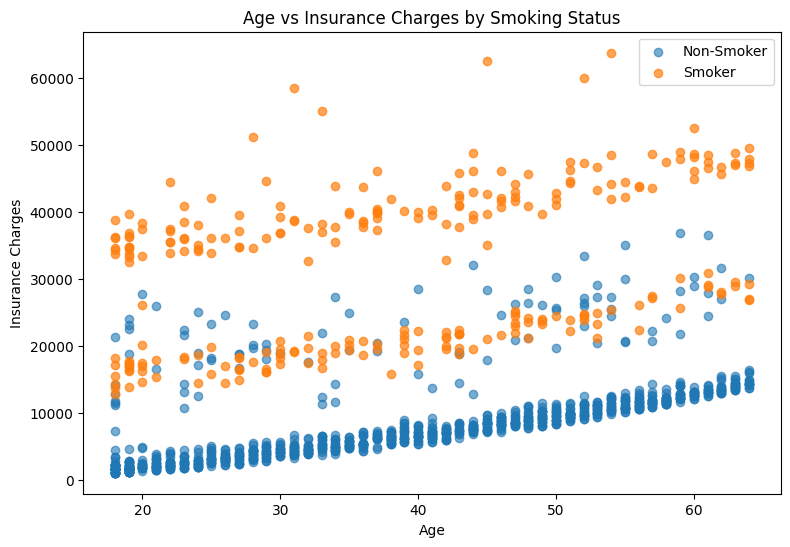

In [28]:
plt.figure(figsize=(9, 6))

non_smokers = df_clean[df_clean["smoker"] == "no"]
smokers = df_clean[df_clean["smoker"] == "yes"]

plt.scatter(
    non_smokers["age"],
    non_smokers["charges"],
    alpha=0.6,
    label="Non-Smoker"
)

plt.scatter(
    smokers["age"],
    smokers["charges"],
    alpha=0.7,
    label="Smoker"
)

plt.title("Age vs Insurance Charges by Smoking Status")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.legend()

plt.show()

In [29]:
smoking_analysis = df_clean.groupby("smoker")["charges"].agg(
    ["count", "mean", "median", "min", "max"]
)

smoking_analysis

,count,mean,median,min,max
smoker,,,,,
no,1063,8440.660307,7345.72660,1121.8739,36910.60803
yes,274,32050.231832,34456.34845,12829.4551,63770.42801


In [30]:
df_clean[["age", "bmi", "children", "charges"]].describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [31]:
correlation_matrix = df_encoded.corr()

correlation_matrix

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
age,1.000000,0.109344,0.041536,0.298308,-0.019814,-0.025587,0.001495,-0.012311,0.009415
bmi,0.109344,1.000000,0.012755,0.198401,0.046397,0.003746,-0.136138,0.270057,-0.006211
children,0.041536,0.012755,1.000000,0.067389,0.017848,0.007331,0.026044,-0.023492,0.021538
charges,0.298308,0.198401,0.067389,1.000000,0.058044,0.787234,-0.038695,0.073578,-0.043637
sex_male,-0.019814,0.046397,0.017848,0.058044,1.000000,0.076596,-0.012482,0.017578,-0.003767
smoker_yes,-0.025587,0.003746,0.007331,0.787234,0.076596,1.000000,-0.036321,0.068282,-0.037168
region_northwest,0.001495,-0.136138,0.026044,-0.038695,-0.012482,-0.036321,1.000000,-0.345909,-0.320493
region_southeast,-0.012311,0.270057,-0.023492,0.073578,0.017578,0.068282,-0.345909,1.000000,-0.346614
region_southwest,0.009415,-0.006211,0.021538,-0.043637,-0.003767,-0.037168,-0.320493,-0.346614,1.000000


In [32]:
charges_correlation = (
    correlation_matrix["charges"]
    .sort_values(ascending=False)
)

print("Correlation with Insurance Charges:")
print(charges_correlation)

Correlation with Insurance Charges:
charges             1.000000
smoker_yes          0.787234
age                 0.298308
bmi                 0.198401
region_southeast    0.073578
children            0.067389
sex_male            0.058044
region_northwest   -0.038695
region_southwest   -0.043637
Name: charges, dtype: float64


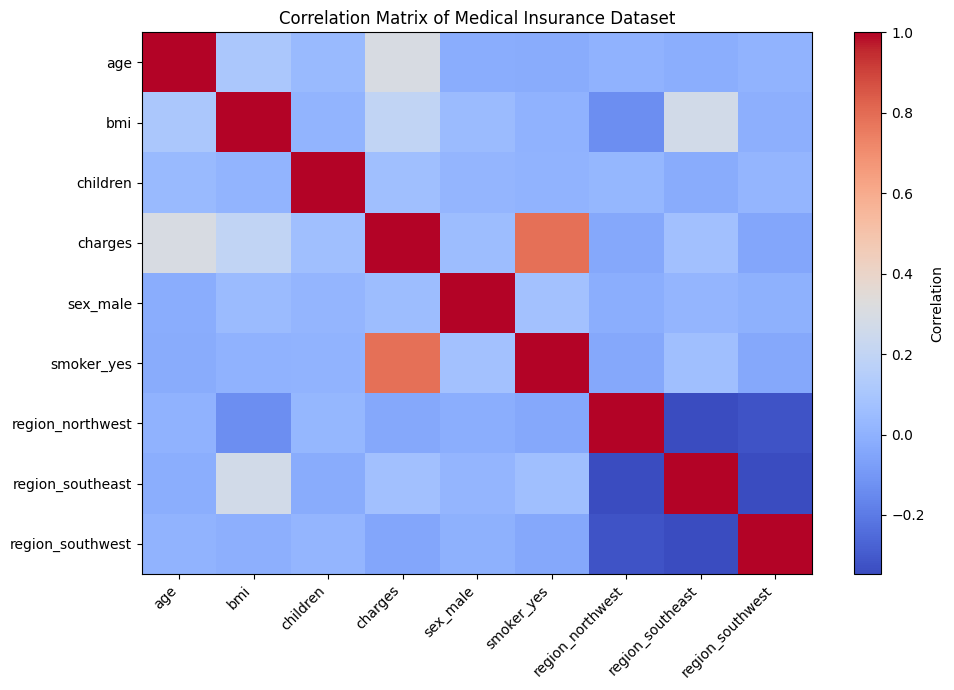

In [33]:
plt.figure(figsize=(10, 7))

plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Medical Insurance Dataset")

plt.tight_layout()
plt.show()

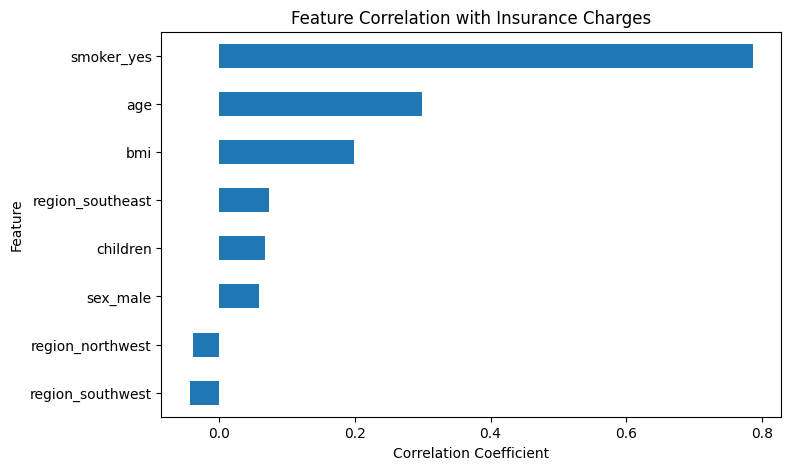

In [34]:
target_correlations = (
    correlation_matrix["charges"]
    .drop("charges")
    .sort_values()
)

plt.figure(figsize=(8, 5))

target_correlations.plot(kind="barh")

plt.title("Feature Correlation with Insurance Charges")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")

plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x79271c970a50>,
 'caps': [<matplotlib.lines.Line2D at 0x79271c972490>,
 'boxes': [<matplotlib.lines.Line2D at 0x79271c971310>,
 'medians': [<matplotlib.lines.Line2D at 0x79271c9734d0>,
 'fliers': [<matplotlib.lines.Line2D at 0x79271c973610>,
 'means': []}

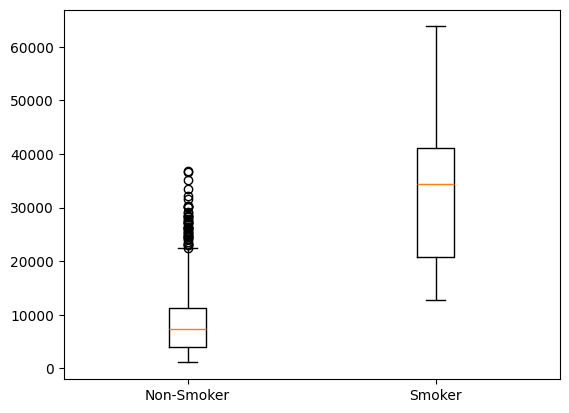

In [35]:
plt.boxplot(smoker_groups, tick_labels=["Non-Smoker", "Smoker"])

## Important Observations

1. **Smoking Status is the strongest predictor:**  
   Smoking status shows the strongest relationship with insurance charges, with a correlation of approximately **0.787**. Smokers have an average insurance charge of about **32,050**, compared with approximately **8,441** for non-smokers.

2. **Age has a positive relationship with charges:**  
   Age has a correlation of approximately **0.298** with insurance charges. The scatter plot also shows that medical insurance costs generally increase as age increases.

3. **BMI shows a weaker positive relationship:**  
   BMI has a correlation of approximately **0.198** with insurance charges. Higher BMI values can be associated with higher costs, although the relationship is more variable than age or smoking status.

4. **Other variables show relatively weak linear relationships:**  
   Children, sex, and region have much smaller correlations with insurance charges compared with smoking status, age, and BMI.

5. **Implication for Model Development:**  
   The exploratory analysis suggests that smoking status will be particularly important for predicting insurance charges, while age and BMI are also useful predictors. These features should therefore contribute significantly to the regression model.

# Phase 5 — Linear Regression Model Training

The prepared dataset is now used to train a Multiple Linear Regression model.

Since the target variable `charges` is a continuous numerical value, Linear
Regression is an appropriate algorithm for this regression problem.

The dataset will be separated into input features (X) and target variable (y),
split into training and testing sets, and then used to train the model.

In [36]:
# Separate input features and target variable

X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

print("X - Input Features:")
display(X.head())

print("\ny - Target Variable:")
display(y.head())

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)

X - Input Features:


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,0,1,0,0,1
1,18,33.770,1,1,0,0,1,0
2,28,33.000,3,1,0,0,1,0
3,33,22.705,0,1,0,1,0,0
4,32,28.880,0,1,0,1,0,0



y - Target Variable:


,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520



X Shape: (1337, 8)
y Shape: (1337,)


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train-Test Split Completed Successfully!")

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Train-Test Split Completed Successfully!

X_train shape: (1069, 8)
X_test shape: (268, 8)
y_train shape: (1069,)
y_test shape: (268,)


In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Multiple Linear Regression Model Trained Successfully!")

Multiple Linear Regression Model Trained Successfully!


In [39]:
print("Model Intercept:", model.intercept_)

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

display(coefficients)

Model Intercept: -11092.65229594595


,Feature,Coefficient
0,age,248.210720
1,bmi,318.701441
2,children,533.009989
3,sex_male,-101.542054
4,smoker_yes,23077.764593
5,region_northwest,-391.761455
6,region_southeast,-838.919616
7,region_southwest,-659.139752


In [40]:
y_pred = model.predict(X_test)

print("Predictions Generated Successfully!")
print("Number of Predictions:", len(y_pred))

Predictions Generated Successfully!
Number of Predictions: 268


In [41]:
prediction_results = pd.DataFrame({
    "Actual Charges": y_test.values,
    "Predicted Charges": y_pred
})

print("Sample Predictions:")
display(prediction_results.head(10))

Sample Predictions:


,Actual Charges,Predicted Charges
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657
5,9304.70190,13149.722353
6,38511.62830,30446.760679
7,2150.46900,1453.288813
8,7345.72660,10633.018402
9,10264.44210,11318.943794


## Model Training Summary

- Input features were separated from the target variable `charges`.
- The dataset was divided into 80% training data and 20% testing data.
- A Multiple Linear Regression model was created using Scikit-learn.
- The model was successfully trained using the training dataset.
- Predictions were generated for previously unseen test data.
- The predicted insurance charges can now be compared with the actual charges during model evaluation.

# Phase 6 — Model Evaluation

The trained Multiple Linear Regression model is evaluated on the unseen test
dataset using standard regression evaluation metrics.

The following metrics are used:
- **MAE (Mean Absolute Error):** Average absolute difference between actual and predicted values.
- **MSE (Mean Squared Error):** Average squared difference between actual and predicted values.
- **RMSE (Root Mean Squared Error):** Square root of MSE, representing prediction error in the same units as insurance charges.
- **R² Score:** Measures how much of the variation in insurance charges is explained by the model.

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MODEL EVALUATION RESULTS")
print("-" * 35)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

MODEL EVALUATION RESULTS
-----------------------------------
Mean Absolute Error (MAE): 4177.05
Mean Squared Error (MSE): 35478020.68
Root Mean Squared Error (RMSE): 5956.34
R² Score: 0.8069


In [43]:
evaluation_results = pd.DataFrame({
    "Actual Charges": y_test.values,
    "Predicted Charges": y_pred,
    "Absolute Error": np.abs(y_test.values - y_pred)
})

print("Actual vs Predicted Insurance Charges:")
display(evaluation_results.head(10))

Actual vs Predicted Insurance Charges:


,Actual Charges,Predicted Charges,Absolute Error
0,8688.85885,8143.693884,545.164966
1,5708.86700,5737.115683,28.248683
2,11436.73815,14369.314876,2932.576726
3,38746.35510,31745.513636,7000.841464
4,4463.20510,8962.386657,4499.181557
5,9304.70190,13149.722353,3845.020453
6,38511.62830,30446.760679,8064.867621
7,2150.46900,1453.288813,697.180187
8,7345.72660,10633.018402,3287.291802
9,10264.44210,11318.943794,1054.501694


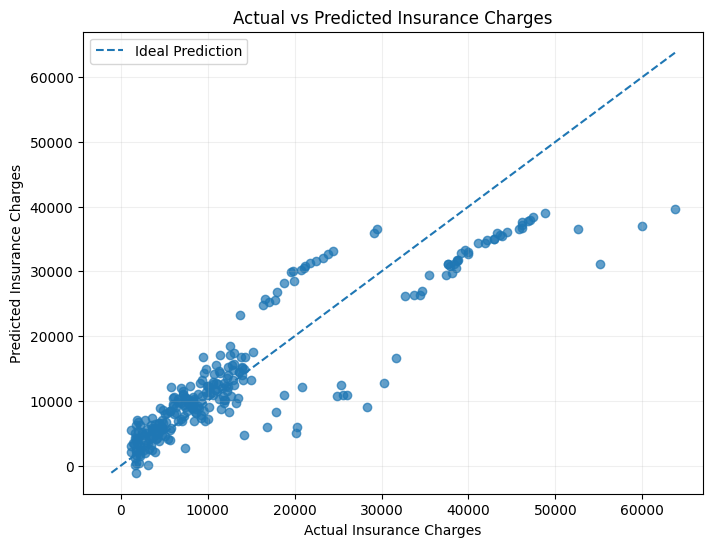

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

# Ideal prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Ideal Prediction"
)

plt.xlabel("Actual Insurance Charges")
plt.ylabel("Predicted Insurance Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [45]:
evaluation_results["Residual"] = (
    evaluation_results["Actual Charges"]
    - evaluation_results["Predicted Charges"]
)

print("Average Absolute Error:", round(
    evaluation_results["Absolute Error"].mean(), 2
))

print("Largest Absolute Error:", round(
    evaluation_results["Absolute Error"].max(), 2
))

display(
    evaluation_results
    .sort_values("Absolute Error", ascending=False)
    .head(5)
)

Average Absolute Error: 4177.05
Largest Absolute Error: 24111.22


,Actual Charges,Predicted Charges,Absolute Error,Residual
34,63770.42801,39659.206889,24111.221121,24111.221121
24,55135.40209,31107.766807,24027.635283,24027.635283
254,60021.39897,36988.215397,23033.183573,23033.183573
124,28340.18885,9028.579983,19311.608867,19311.608867
79,30259.99556,12811.716568,17448.278992,17448.278992


## Model Evaluation — Key Findings

The Multiple Linear Regression model achieved an **R² score of 0.8069**, meaning
that it explains approximately **80.7% of the variation in medical insurance
charges** on the test dataset.

The model produced:

- **MAE:** 4,177.05
- **MSE:** 35,478,020.68
- **RMSE:** 5,956.34
- **R² Score:** 0.8069

The MAE indicates that predictions differ from the actual insurance charges by
approximately 4,177 on average.

The Actual vs Predicted plot shows that many predictions follow the expected
trend, although larger errors occur for some high-cost observations.

The largest absolute error observed in the test set was approximately **24,111**.

Overall, the Linear Regression model captures a substantial portion of the
variation in insurance charges, but the remaining prediction errors suggest
that the relationship between the features and charges is not perfectly linear.

# Phase 7 — Insurance Cost Prediction Application

A simple prediction application is built using the trained Multiple Linear Regression model.

The user can enter personal and lifestyle information such as age, BMI, number of children,
gender, smoking status, and region.

The application converts these inputs into the same numerical format used during model training
and returns the estimated medical insurance charge.

In [48]:
!pip install -q gradio


In [47]:
import gradio as gr
import pandas as pd

def predict_insurance(age, bmi, children, gender, smoker, region):

    # Create input using the exact feature structure used during training
    input_data = {
        "age": age,
        "bmi": bmi,
        "children": children,
        "sex_male": 1 if gender == "Male" else 0,
        "smoker_yes": 1 if smoker == "Yes" else 0,
        "region_northwest": 1 if region == "Northwest" else 0,
        "region_southeast": 1 if region == "Southeast" else 0,
        "region_southwest": 1 if region == "Southwest" else 0
    }

    input_df = pd.DataFrame([input_data])

    # Ensure same column order as training data
    input_df = input_df[X.columns]

    prediction = model.predict(input_df)[0]

    return f"Estimated Insurance Cost: {prediction:,.2f}"


demo = gr.Interface(
    fn=predict_insurance,

    inputs=[
        gr.Slider(18, 64, value=30, step=1, label="Age"),
        gr.Slider(15, 55, value=25, step=0.1, label="BMI"),
        gr.Slider(0, 5, value=0, step=1, label="Number of Children"),
        gr.Radio(["Female", "Male"], label="Gender"),
        gr.Radio(["No", "Yes"], label="Smoker"),
        gr.Dropdown(
            ["Northeast", "Northwest", "Southeast", "Southwest"],
            label="Region"
        )
    ],

    outputs=gr.Textbox(label="Prediction Result"),

    title="Medical Insurance Cost Predictor",

    description=(
        "Enter customer information below to estimate medical insurance charges "
        "using the trained Multiple Linear Regression model."
    )
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7733f82509bf0f2b5c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Prediction Application — Outcome

The trained Linear Regression model was successfully integrated into an
interactive Gradio application.

The application accepts age, BMI, number of children, gender, smoking status,
and region as user inputs and generates an estimated medical insurance cost.

Two different test cases were used to verify that the application produces
different predictions based on the customer profile.

This demonstrates how the trained machine learning model can be used to make
predictions on new, unseen user data through a simple interactive interface.
